In [61]:

# Just a few imports
import numpy as np
import matplotlib.pyplot as plt
from bloch_schrodinger.potential import Potential, create_parameter
from bloch_schrodinger.plotting import plot_cuts, plot_eigenvector

# First, we define a few constants

kl = 2 # Laser wavevector
a = 4 * np.pi / 3**1.5 / kl # Lattice constant
a1 = np.array([3 * a / 2, -(3**0.5) * a / 2])  # 1st lattice vector
a2 = np.array([3 * a / 2, 3**0.5 * a / 2])  # 2nd lattice vector

# Reciprocal vectors
b1 = 3**0.5 * kl * np.array([1, -(3**0.5)]) / 2
b2 = 3**0.5 * kl * np.array([1, 3**0.5]) / 2

m = 1
hbar = 1
E_r = hbar**2 * kl**2 / 2 / m # Recoil energy

# --- We are going to create a honeycomb lattice with on-site energy differences ---
s1 = 10 # Laser intensity in recoil energy unit
s2 = s1 + -0.1#create_parameter("delta", np.linspace(-0.2, 0.2, 3))

# Laser directions
k1 = kl * np.array([-(3**0.5) / 2, 1 / 2])
k2 = kl * np.array([3**0.5 / 2, 1 / 2])
k3 = kl * np.array([0, -1])

# Reciprocal space vectors
a1s = np.array([-1, 3**0.5]) * 2 * np.pi / 3 / a
a2s = np.array([1, 3**0.5]) * 2 * np.pi / 3 / a
K = np.array([0, 4 * np.pi / 3**1.5 / a])


Now, we build the potential exactly as for the finite-difference solver, using the `Potential` class. The only difference is that the potential resolution chosen is not going to affect the solver's performance (as long as the underlying potential is sampled enough, which is not going to be an issue here).

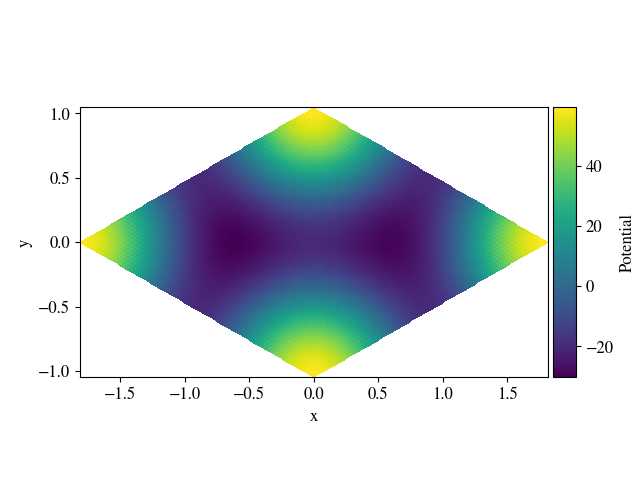

In [62]:

na1 = 64
na2 = 64

V1 = -s1 * E_r
V2 = -s2 * E_r

honeycomb = Potential(
    unitvecs=[a1, a2],
    resolution=(na1, na2),
    v0=0,
)

dirs = [
    k1[0] * (honeycomb.x - a1[0]) + k1[1] * honeycomb.y,
    k2[0] * (honeycomb.x - a1[0]) + k2[1] * honeycomb.y,
    k3[0] * (honeycomb.x - a1[0]) + k3[1] * honeycomb.y,
]

for i in range(3):
    honeycomb.add(2 * V1 * np.cos((dirs[i - 1] - dirs[i]) - 2 * np.pi / 3) / 2)
    honeycomb.add(2 * V2 * np.cos((dirs[i - 1] - dirs[i]) + 2 * np.pi / 3) / 2)

%matplotlib widget
honeycomb.plot()
plt.show()

In [63]:
from BECs.nleigve import NLEigve

g = create_parameter('g', np.linspace(0,20, 10))
interactions = Potential(
    unitvecs=[a1, a2],
    resolution=(na1, na2),
    v0=g*200,
)

foo = NLEigve(
    honeycomb, alphas=hbar**2/2/m, gs = interactions
)

foo.create_reciprocal_grid(
    ky=np.linspace(-a1s[1], a1s[1], 55), # Solving for 55 k-points
    kx=0,
)

eigva, eigve = foo.solve(
    n_eig=2,
    population=10,
    parallel=True,
    tol = 1e-2
)

Performing 550 diagonalizations...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 20 concurrent workers.
[Parallel(n_jobs=-1)]: Done  32 tasks      | elapsed:    0.7s
[Parallel(n_jobs=-1)]: Done 204 tasks      | elapsed:    5.1s
[Parallel(n_jobs=-1)]: Done 348 tasks      | elapsed:    9.7s
[Parallel(n_jobs=-1)]: Done 510 tasks      | elapsed:   14.8s
[Parallel(n_jobs=-1)]: Done 550 out of 550 | elapsed:   15.9s finished


storing the results


100%|██████████| 550/550 [00:00<00:00, 645.88it/s]


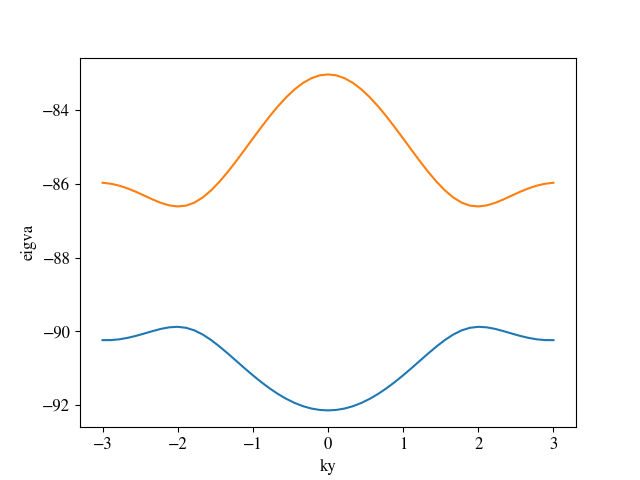

In [64]:
plot_cuts(
    eigva, 'ky', groupby=['band']
)

plt.show()

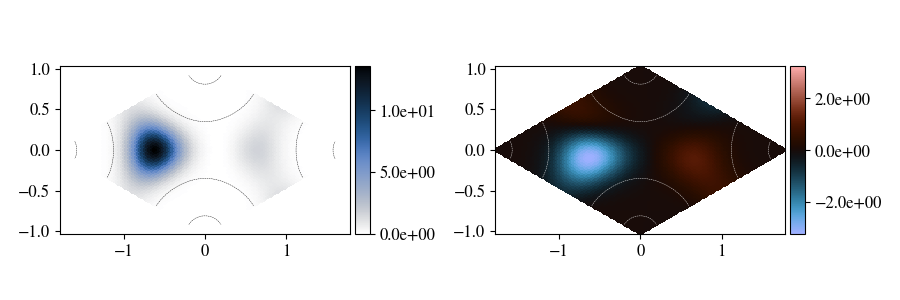

In [65]:
plot_eigenvector(
    [[abs(eigve)**2, eigve.real]], [[honeycomb, honeycomb]], [['amplitude', 'real']]
)
plt.show()